# Synthetic demo: Scaled baseline vs Hawkes

This notebook runs the univariate Hawkes model on a single synthetic sequence and compares it to the **scaled baseline**.


In [1]:
import sys
from pathlib import Path
import os

# Make repo importable regardless of where Jupyter was started
ROOT = Path.cwd().resolve()
for _ in range(6):
    if (ROOT / 'src').is_dir():
        break
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Avoid font/cache issues in restricted environments
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from src.datasets import generate_synthetic_sequences
from src.utils import temporal_train_test_split
from src.baselines import HourlySeasonalPoisson, ScaledBaseline
from src.hawkes import HawkesExp
from src.experiments import calc_test_ll

sequences, truth = generate_synthetic_sequences(n_users=20, seed=42)
print('n_sequences:', len(sequences))
truth.head()


n_sequences: 18


,user_id,alpha,beta,mu,branching_ratio,events
0,user_0,1.438055,4.095824,0.264649,0.351103,54
1,user_1,2.791534,3.651457,0.121612,0.764499,47
2,user_2,2.840336,4.946526,0.287799,0.574208,49
3,user_4,0.126893,4.290332,0.143176,0.029577,21
4,user_6,0.459531,1.262122,0.179022,0.364094,53


In [3]:
# Pick one sequence and split
seq = sequences[0]
times = sorted(seq['times'])
train_times, test_times, _, _ = temporal_train_test_split(times, train_ratio=0.8)

len(times), len(train_times), len(test_times), (train_times[0], test_times[-1])


(54,
 44,
 10,
 (Timestamp('2024-01-01 01:24:34.684414267'),
  Timestamp('2024-01-07 21:21:52.307341620')))

In [4]:
# Fit baseline + scaled baseline (MLE mu) + Hawkes
base = HourlySeasonalPoisson().fit(train_times)
scaled = ScaledBaseline(base).fit(train_times)
hawkes = HawkesExp(baseline=base).fit(train_times)

ll_baseline = calc_test_ll(scaled, train_times, test_times)
ll_hawkes = calc_test_ll(hawkes, train_times, test_times)

print('seq_id:', seq['id'])
print('mu (scaled baseline):', scaled.mu)
print('hawkes params [mu, alpha, beta]:', hawkes.params)
print('ll_baseline (per test event):', ll_baseline)
print('ll_hawkes   (per test event):', ll_hawkes)
print('ll_gain:', ll_hawkes - ll_baseline)


seq_id: user_0
mu (scaled baseline): 0.9822041464807848
hawkes params [mu, alpha, beta]: [0.7394422722534307, 1.8422733036469863, 7.206373653062128]
ll_baseline (per test event): -18.506346594005763
ll_hawkes   (per test event): -8.462373776854799
ll_gain: 10.043972817150964


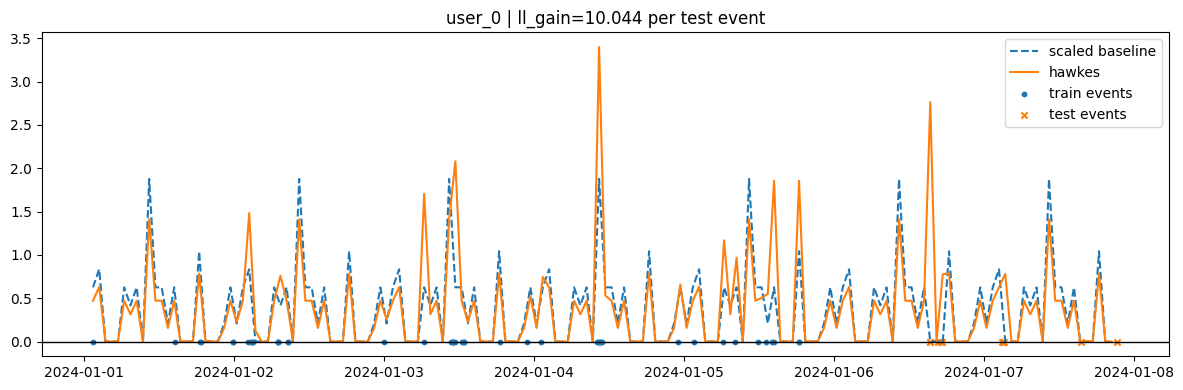

In [5]:
# Visual sanity check: intensity over time with events
t0 = train_times[0]
t1 = test_times[-1]
grid = pd.date_range(t0, t1, freq='1h')

hist = []
l_base = []
l_hawk = []
idx = 0
events = sorted(train_times + test_times)

for t in grid:
    while idx < len(events) and events[idx] <= t:
        hist.append(events[idx])
        idx += 1
    l_base.append(scaled.get_intensity(t))
    l_hawk.append(hawkes.get_intensity(t, hist))

plt.figure(figsize=(12, 4))
plt.plot(grid, l_base, label='scaled baseline', linestyle='--')
plt.plot(grid, l_hawk, label='hawkes')
plt.scatter(train_times, [0] * len(train_times), s=10, label='train events')
plt.scatter(test_times, [0] * len(test_times), s=20, marker='x', label='test events')
plt.axhline(0, color='black', linewidth=1)
plt.legend()
plt.title(f"{seq['id']} | ll_gain={ll_hawkes - ll_baseline:.3f} per test event")
plt.tight_layout()
plt.show()
